a)

Leave-One-Out cross-validation  (N_LOO = 6 per class)

Dataset σ²=0.25   Bayes error=2.28%
    i   x_test C1   x_test C2   pred C1   pred C2   errors
  ----------------------------------------------------------
    1     -0.8476      0.9704       →C1       →C2        0
    2     -1.5200      0.6354       →C1       →C2        0
    3     -0.6248      0.7928       →C1       →C2        0
    4     -0.5297      1.3170       →C1       →C2        0
    5     -1.9755      1.0015       →C1       →C2        0
    6     -1.6511      1.1701       →C1       →C2        0
  ──────────────────────────────────────────────────────────
  LOO avg error rate : 0.00%   (0 errors / 12 classifications)
  Bayes error        : 2.28%

Dataset σ²=0.49   Bayes error=7.66%
    i   x_test C1   x_test C2   pred C1   pred C2   errors
  ----------------------------------------------------------
    1     -1.3164      1.8743       →C1       →C2        0
    2     -1.4661      1.4814       →C1       →C2        0
    3  

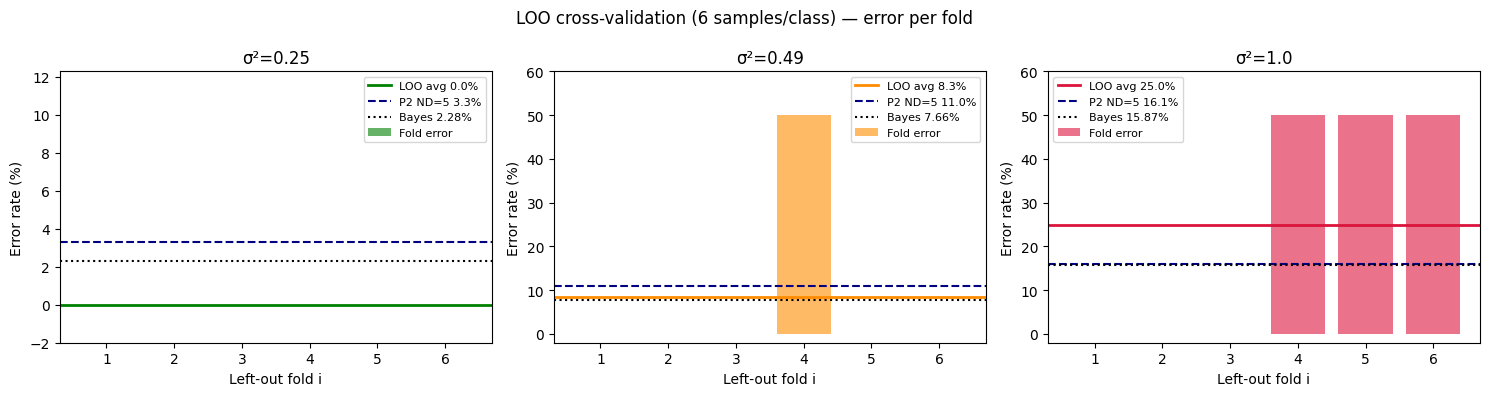

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# ── Dataset definitions ───────────────────────────────────────────────────────
datasets = [
    ("datasets/dataset_1_sigma2_025.npy", 0.25),
    ("datasets/dataset_2_sigma2_049.npy", 0.49),
    ("datasets/dataset_3_sigma2_10.npy",  1.00),
]

N_LOO    = 6    # total samples per class used
m1_true, m2_true = -1.0, 1.0

def gauss_classify(X, mu1, mu2, sigma):
    """Equal-prior Gaussian classifier (pooled σ)."""
    ll1 = -0.5 * ((X - mu1) / sigma) ** 2
    ll2 = -0.5 * ((X - mu2) / sigma) ** 2
    return (ll2 >= ll1).astype(int)

print("Leave-One-Out cross-validation  (N_LOO = 6 per class)")
print("=" * 68)

all_loo = {}   # sigma2 -> list of (x_test_c1, x_test_c2, pred_c1, pred_c2, correct)

for ds_path, sigma2 in datasets:
    data     = np.load(ds_path)
    # First 6 training samples from each class
    pool_c1  = data[:6,    0]   # indices 0-5
    pool_c2  = data[1000:1006, 0]

    bayes_pe = 0.5 * erfc(abs(m2_true - m1_true) / (2 * np.sqrt(sigma2) * np.sqrt(2)))

    print(f"\nDataset σ²={sigma2}   Bayes error={bayes_pe*100:.2f}%")
    print(f"  {'i':>3}  {'x_test C1':>10}  {'x_test C2':>10}  "
          f"{'pred C1':>8}  {'pred C2':>8}  {'errors':>7}")
    print(f"  {'-'*58}")

    errors_per_fold = []
    fold_details    = []

    for i in range(N_LOO):
        # Leave sample i out for testing
        x_test = np.array([pool_c1[i], pool_c2[i]])
        y_test = np.array([0, 1])

        tr_c1 = np.delete(pool_c1, i)   # 5 remaining training samples
        tr_c2 = np.delete(pool_c2, i)

        # MLE estimates from 5 training samples
        mu1h = np.mean(tr_c1)
        mu2h = np.mean(tr_c2)
        sh   = np.sqrt((np.var(tr_c1, ddof=1) + np.var(tr_c2, ddof=1)) / 2)

        y_pred = gauss_classify(x_test, mu1h, mu2h, sh)
        n_err  = np.sum(y_pred != y_test)
        errors_per_fold.append(n_err / 2)   # 2 test samples per fold

        fold_details.append((pool_c1[i], pool_c2[i], y_pred[0], y_pred[1],
                             n_err, mu1h, mu2h, sh))

        pred_str_c1 = "C1" if y_pred[0] == 0 else "C2"
        pred_str_c2 = "C1" if y_pred[1] == 0 else "C2"
        print(f"  {i+1:>3}  {pool_c1[i]:>10.4f}  {pool_c2[i]:>10.4f}  "
              f"{'→'+pred_str_c1:>8}  {'→'+pred_str_c2:>8}  {n_err:>7}")

    avg_err = np.mean(errors_per_fold)
    total_correct = sum(2 - d[4] for d in fold_details)
    print(f"  {'─'*58}")
    print(f"  LOO avg error rate : {avg_err*100:.2f}%   "
          f"({sum(d[4] for d in fold_details)} errors / {N_LOO*2} classifications)")
    print(f"  Bayes error        : {bayes_pe*100:.2f}%")

    all_loo[sigma2] = (fold_details, avg_err, bayes_pe)

# ── Comparison with Problem 2 (ND=5) ─────────────────────────────────────────
# Re-run Problem 2 ND=5 for each dataset with a fixed seed for fair comparison
rng_p2 = np.random.default_rng(seed=42)

# These are the same avg errors recorded from Task 2 cell 1 (ND=5 run)
# We recompute them here for a self-contained comparison
p2_nd5_errs = {}
for ds_path, sigma2 in datasets:
    data     = np.load(ds_path)
    train_c1 = data[:500,      0]
    train_c2 = data[1000:1500, 0]
    X_test   = np.concatenate([data[500:1000, 0], data[1500:2000, 0]])
    y_test   = np.concatenate([np.zeros(500, int), np.ones(500, int)])
    idx1 = rng_p2.permutation(500)
    idx2 = rng_p2.permutation(500)
    ND = 5
    errs = []
    for rep in range(5):
        s, e  = rep*ND, (rep+1)*ND
        tr_c1 = train_c1[idx1[s:e]]; tr_c2 = train_c2[idx2[s:e]]
        mu1h  = np.mean(tr_c1); mu2h = np.mean(tr_c2)
        sh    = np.sqrt((np.var(tr_c1, ddof=1) + np.var(tr_c2, ddof=1)) / 2)
        y_pred = gauss_classify(X_test, mu1h, mu2h, sh)
        errs.append(np.mean(y_pred != y_test))
    p2_nd5_errs[sigma2] = np.mean(errs)

print("\n" + "=" * 68)
print("Comparison: LOO (N=6)  vs  Problem 2 ND=5  vs  Bayes error")
print("=" * 68)
print(f"{'σ²':>6}  {'LOO err':>10}  {'P2 ND=5 err':>13}  {'Bayes err':>11}")
print(f"{'-'*46}")
for _, sigma2 in datasets:
    _, loo_err, bayes_pe = all_loo[sigma2]
    p2_err = p2_nd5_errs[sigma2]
    print(f"{sigma2:>6}  {loo_err*100:>9.2f}%  {p2_err*100:>12.2f}%  {bayes_pe*100:>10.2f}%")
print("=" * 68)

# ── Visual summary ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {0.25: "green", 0.49: "darkorange", 1.00: "crimson"}

for ax, (ds_path, sigma2) in zip(axes, datasets):
    fold_details, loo_err, bayes_pe = all_loo[sigma2]
    p2_err = p2_nd5_errs[sigma2]
    col = colors[sigma2]

    fold_errs = [d[4] / 2 * 100 for d in fold_details]
    ax.bar(range(1, N_LOO+1), fold_errs, color=col, alpha=0.6, label="Fold error")
    ax.axhline(loo_err*100,  color=col,     linestyle="-",  lw=2,   label=f"LOO avg {loo_err*100:.1f}%")
    ax.axhline(p2_err*100,   color="navy",  linestyle="--", lw=1.5, label=f"P2 ND=5 {p2_err*100:.1f}%")
    ax.axhline(bayes_pe*100, color="black", linestyle=":",  lw=1.5, label=f"Bayes {bayes_pe*100:.2f}%")

    ax.set_title(f"σ²={sigma2}")
    ax.set_xlabel("Left-out fold i")
    ax.set_ylabel("Error rate (%)")
    ax.set_xticks(range(1, N_LOO+1))
    ax.set_ylim(-2, max(max(fold_errs)+10, bayes_pe*100+10))
    ax.legend(fontsize=8)

plt.suptitle("LOO cross-validation (6 samples/class) — error per fold", fontsize=12)
plt.tight_layout()
plt.show()